In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/binovi/wholesale-customers-data-set/Wholesale customers data.csv


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [3]:
df = pd.read_csv("/kaggle/input/datasets/binovi/wholesale-customers-data-set/Wholesale customers data.csv")

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows: 0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (440, 8)


In [8]:
channel_names = {
    1: "Horeca",
    2: "Retail"
}

region_names = {
    1: "Lisbon",
    2: "Oporto",
    3: "Other"
}

print("Channel distribution:")
print(df["Channel"].map(channel_names).value_counts())

print("\nRegion distribution:")
print(df["Region"].map(region_names).value_counts())

Channel distribution:
Channel
Horeca    298
Retail    142
Name: count, dtype: int64

Region distribution:
Region
Other     316
Lisbon     77
Oporto     47
Name: count, dtype: int64


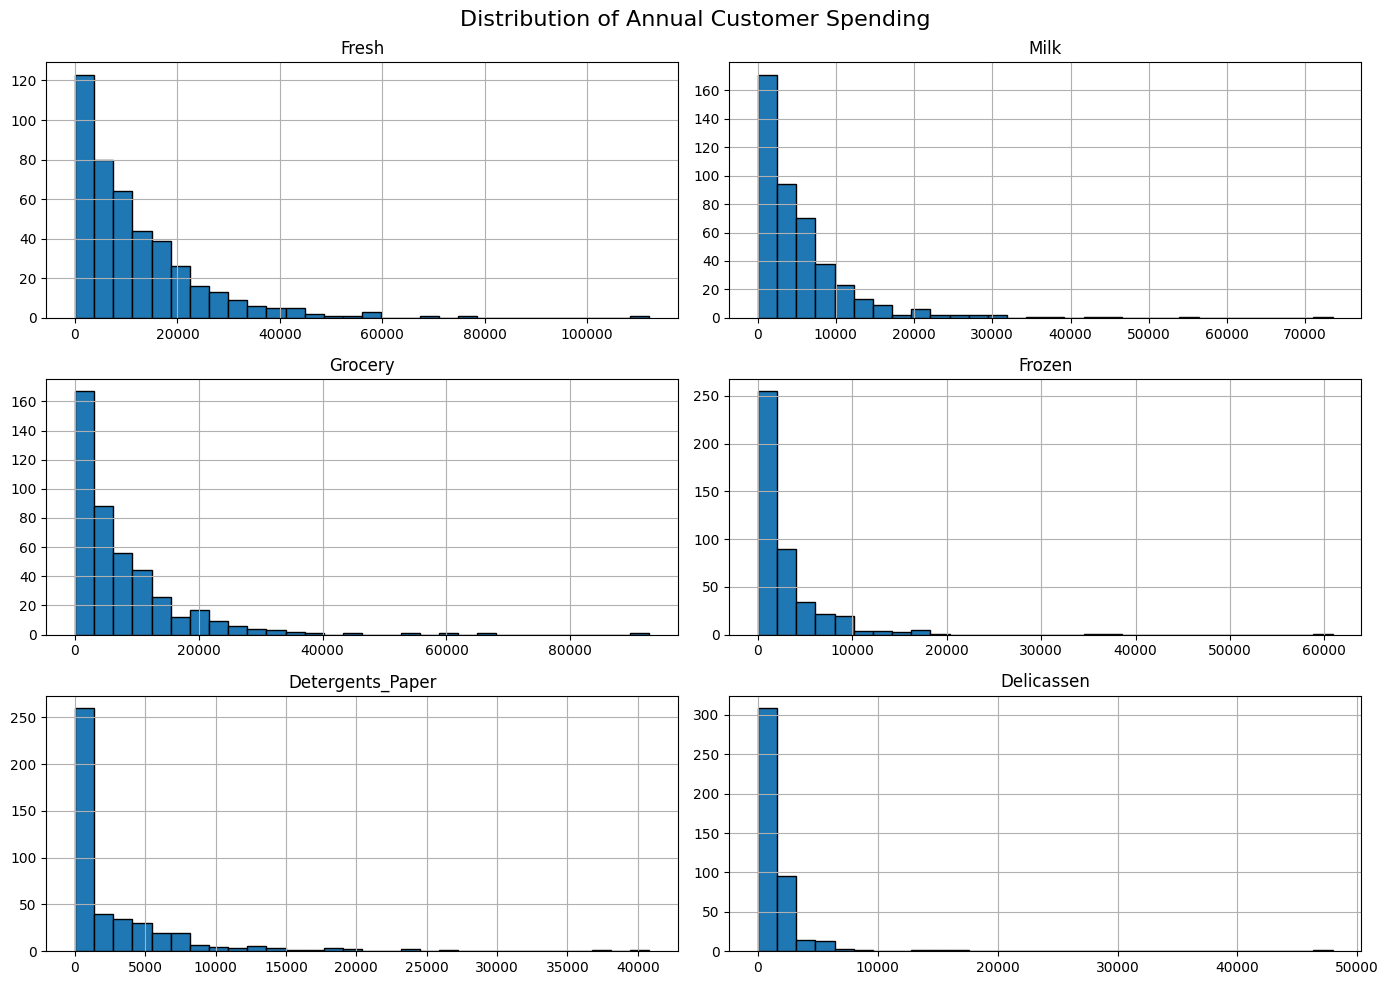

In [9]:
spending_columns = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

df[spending_columns].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Distribution of Annual Customer Spending", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
print("Feature skewness:")
print(df[spending_columns].skew().sort_values(ascending=False))

Feature skewness:
Delicassen          11.151586
Frozen               5.907986
Milk                 4.053755
Detergents_Paper     3.631851
Grocery              3.587429
Fresh                2.561323
dtype: float64


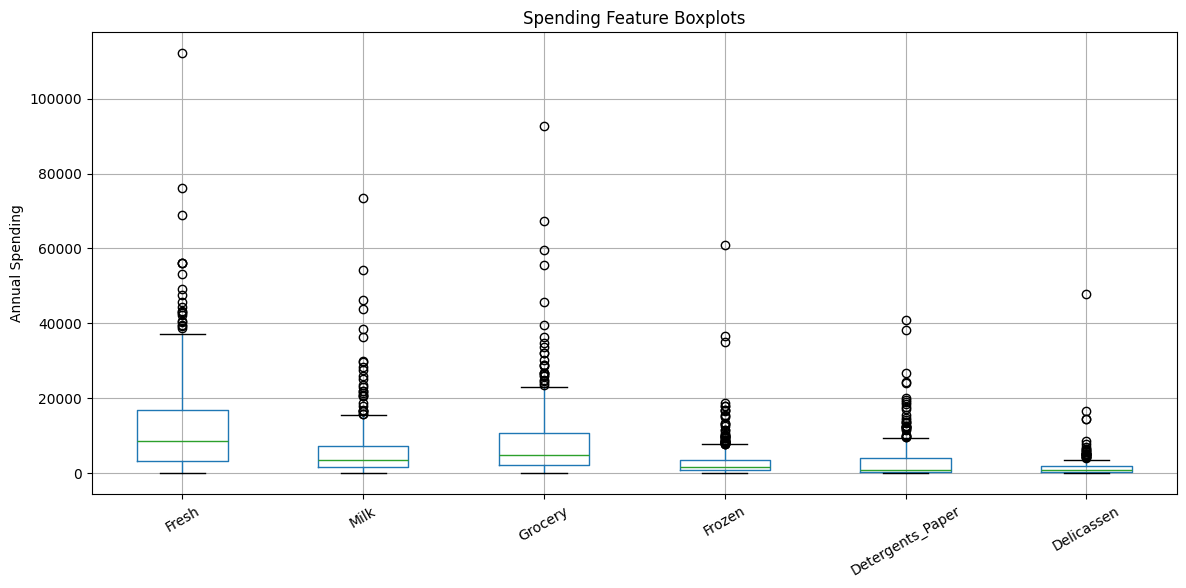

In [11]:
plt.figure(figsize=(14, 6))
df[spending_columns].boxplot()
plt.title("Spending Feature Boxplots")
plt.ylabel("Annual Spending")
plt.xticks(rotation=30)
plt.show()

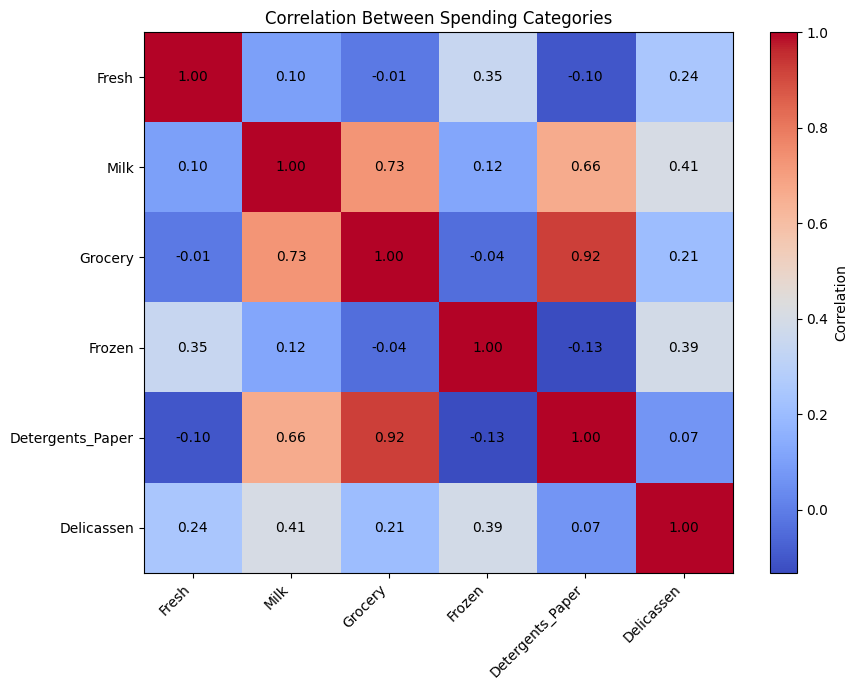

In [12]:
correlation_matrix = df[spending_columns].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(spending_columns)),
    spending_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(spending_columns)),
    spending_columns
)

for i in range(len(spending_columns)):
    for j in range(len(spending_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Spending Categories")
plt.tight_layout()
plt.show()

In [13]:
channel_summary = (
    df.assign(Channel_Name=df["Channel"].map(channel_names))
      .groupby("Channel_Name")[spending_columns]
      .mean()
      .round(2)
)

channel_summary

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel_Name,,,,,,
Horeca,13475.56,3451.72,3962.14,3748.25,790.56,1415.96
Retail,8904.32,10716.50,16322.85,1652.61,7269.51,1753.44


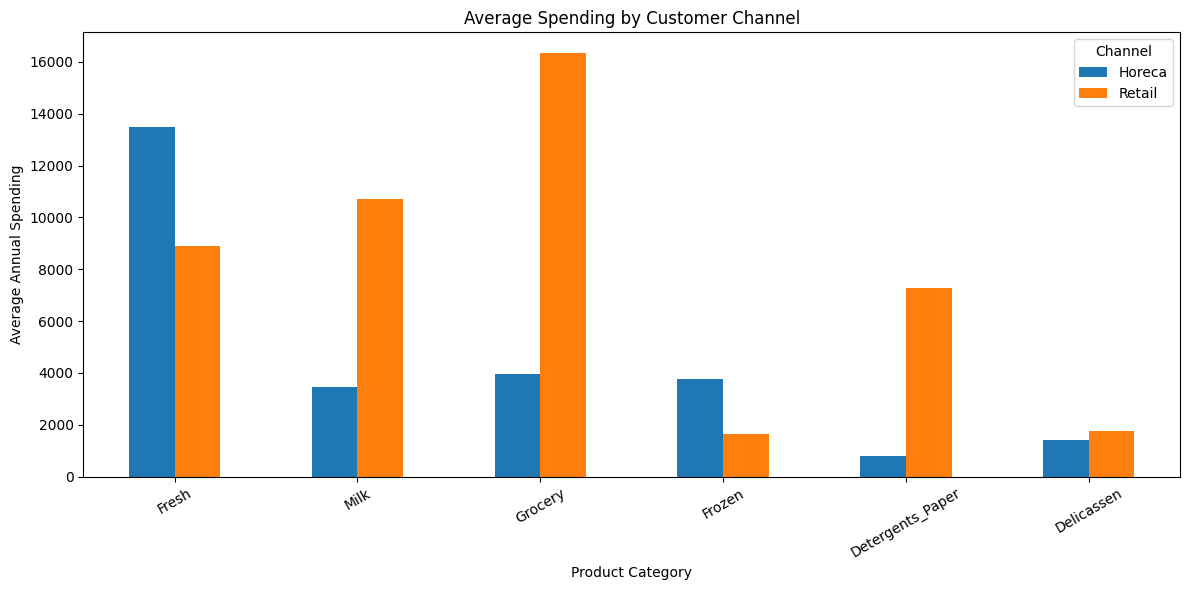

In [14]:
channel_summary.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Spending by Customer Channel")
plt.xlabel("Product Category")
plt.ylabel("Average Annual Spending")
plt.xticks(rotation=30)
plt.legend(title="Channel")
plt.tight_layout()
plt.show()

In [15]:
X = df[spending_columns].copy()

X_log = np.log1p(X)

print("Skewness before log transformation:")
print(X.skew().round(2))

print("\nSkewness after log transformation:")
print(X_log.skew().round(2))

Skewness before log transformation:
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64

Skewness after log transformation:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=spending_columns
)

X_scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


In [17]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

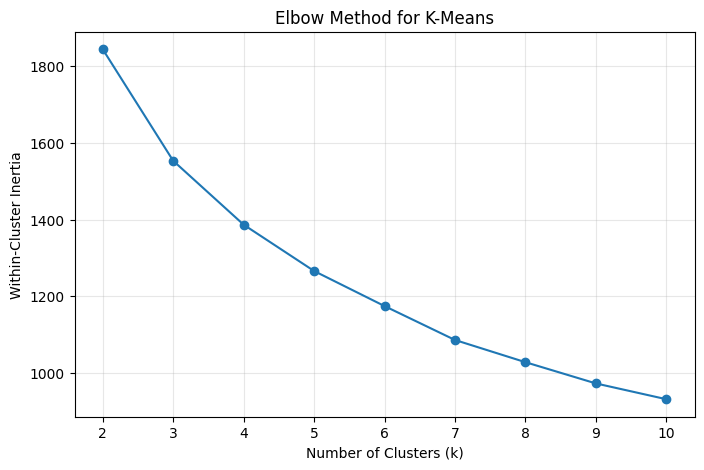

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Inertia")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

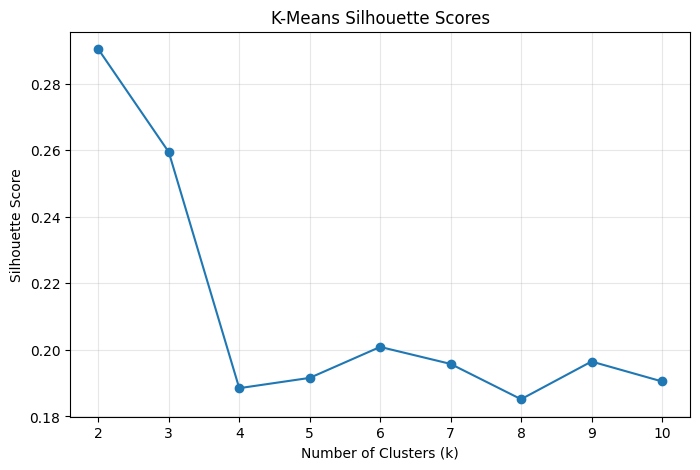

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

In [20]:
k_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

k_results

,k,Inertia,Silhouette Score
0,2,1844.064069,0.290328
1,3,1553.421327,0.259416
2,4,1386.862741,0.188495
3,5,1266.149362,0.191585
4,6,1174.758633,0.200887
5,7,1086.358700,0.195780
6,8,1028.486217,0.185175
7,9,973.141483,0.196501
8,10,931.998464,0.190523


For this dataset, the elbow frequently appears around k = 3, although your plot should determine the final choice.

In [21]:
best_k = 3

In [22]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means cluster counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())

print(
    "\nK-Means silhouette score:",
    round(silhouette_score(X_scaled, df["KMeans_Cluster"]), 3)
)

K-Means cluster counts:
KMeans_Cluster
0     80
1    147
2    213
Name: count, dtype: int64

K-Means silhouette score: 0.259


DBSCAN

In [23]:
min_samples = 6

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

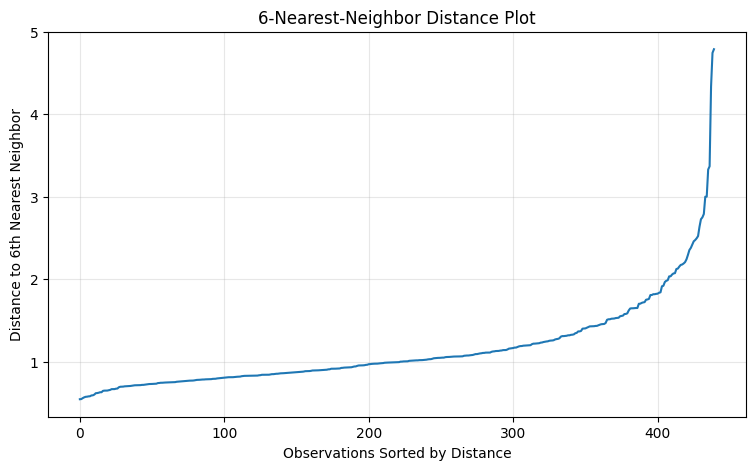

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.title(f"{min_samples}-Nearest-Neighbor Distance Plot")
plt.xlabel("Observations Sorted by Distance")
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbor")
plt.grid(alpha=0.3)
plt.show()

In [25]:
dbscan_results = []

eps_values = np.arange(0.4, 1.51, 0.05)
min_samples_values = [4, 5, 6, 8, 10]

for eps in eps_values:
    for min_samples_value in min_samples_values:
        
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples_value
        )
        
        labels = model.fit_predict(X_scaled)
        
        # Exclude noise label (-1) when counting clusters
        cluster_labels = set(labels)
        n_clusters = len(cluster_labels - {-1})
        n_noise = np.sum(labels == -1)
        
        # Compute silhouette only on non-noise observations
        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]
        
        if (
            n_clusters >= 2
            and len(set(non_noise_labels)) >= 2
            and non_noise_mask.sum() > n_clusters
        ):
            score = silhouette_score(
                X_scaled[non_noise_mask],
                non_noise_labels
            )
        else:
            score = np.nan
        
        dbscan_results.append({
            "eps": round(eps, 2),
            "min_samples": min_samples_value,
            "Clusters": n_clusters,
            "Noise Points": n_noise,
            "Noise Percentage": round(
                n_noise / len(df) * 100,
                2
            ),
            "Silhouette Score": score
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

In [26]:
valid_dbscan_results = (
    dbscan_results_df[
        (dbscan_results_df["Clusters"].between(2, 6))
        & (dbscan_results_df["Noise Percentage"] < 40)
    ]
    .sort_values(
        by=["Silhouette Score", "Noise Percentage"],
        ascending=[False, True]
    )
)

valid_dbscan_results.head(15)

,eps,min_samples,Clusters,Noise Points,Noise Percentage,Silhouette Score
51,0.90,5,3,160,36.36,0.274144
74,1.10,10,2,122,27.73,0.261278
58,0.95,8,2,171,38.86,0.255246
62,1.00,6,2,129,29.32,0.253783
67,1.05,6,2,115,26.14,0.253351
56,0.95,5,3,141,32.05,0.249900
63,1.00,8,2,146,33.18,0.245019
57,0.95,6,3,147,33.41,0.237472
68,1.05,8,2,120,27.27,0.228594
85,1.25,4,2,59,13.41,0.196734


In [27]:
if len(valid_dbscan_results) > 0:
    selected_result = valid_dbscan_results.iloc[0]
    
    best_eps = float(selected_result["eps"])
    best_min_samples = int(selected_result["min_samples"])
else:
    # Fallback values if the search produces no acceptable result
    best_eps = 0.8
    best_min_samples = 6

print("Selected eps:", best_eps)
print("Selected min_samples:", best_min_samples)

Selected eps: 0.9
Selected min_samples: 5


In [28]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = len(
    set(df["DBSCAN_Cluster"]) - {-1}
)

n_noise = (df["DBSCAN_Cluster"] == -1).sum()

print("DBSCAN cluster counts:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

print("\nNumber of DBSCAN clusters:", n_dbscan_clusters)
print("Number of noise points:", n_noise)
print("Noise percentage:", round(n_noise / len(df) * 100, 2), "%")

DBSCAN cluster counts:
DBSCAN_Cluster
-1    160
 0    262
 1     10
 2      8
Name: count, dtype: int64

Number of DBSCAN clusters: 3
Number of noise points: 160
Noise percentage: 36.36 %


In [29]:
non_noise_mask = df["DBSCAN_Cluster"] != -1

if (
    n_dbscan_clusters >= 2
    and non_noise_mask.sum() > n_dbscan_clusters
):
    dbscan_silhouette = silhouette_score(
        X_scaled[non_noise_mask],
        df.loc[non_noise_mask, "DBSCAN_Cluster"]
    )
    
    print(
        "DBSCAN silhouette score excluding noise:",
        round(dbscan_silhouette, 3)
    )
else:
    dbscan_silhouette = np.nan
    print("DBSCAN did not produce enough clusters for a silhouette score.")

DBSCAN silhouette score excluding noise: 0.274


In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

print(
    "Explained variance by two components:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

print("Individual explained variance ratios:")
print(pca.explained_variance_ratio_)

Explained variance by two components: 71.27 %
Individual explained variance ratios:
[0.44077752 0.27194917]


In [31]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=spending_columns,
    columns=["PCA1", "PCA2"]
)

pca_loadings

,PCA1,PCA2
Fresh,-0.105250,0.590359
Milk,0.542329,0.132911
Grocery,0.571472,-0.005751
Frozen,-0.137910,0.589778
Detergents_Paper,0.550642,-0.070822
Delicassen,0.214469,0.530022


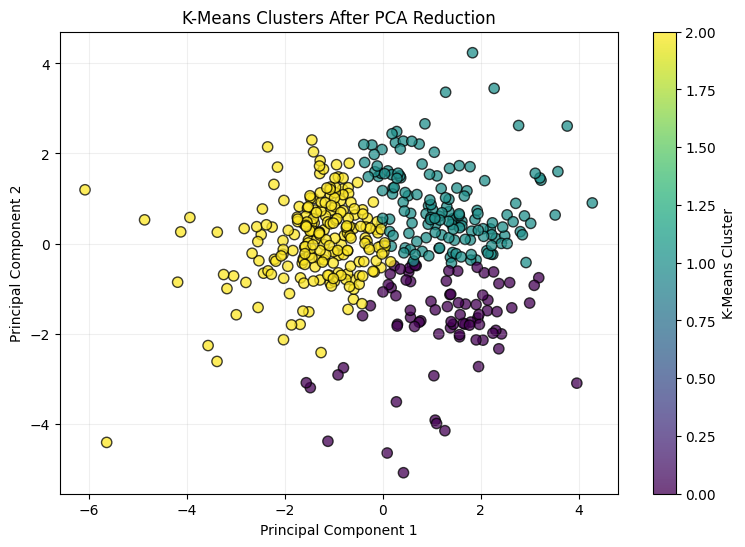

In [32]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=55,
    alpha=0.75,
    edgecolor="black"
)

plt.colorbar(scatter, label="K-Means Cluster")
plt.title("K-Means Clusters After PCA Reduction")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.2)
plt.show()

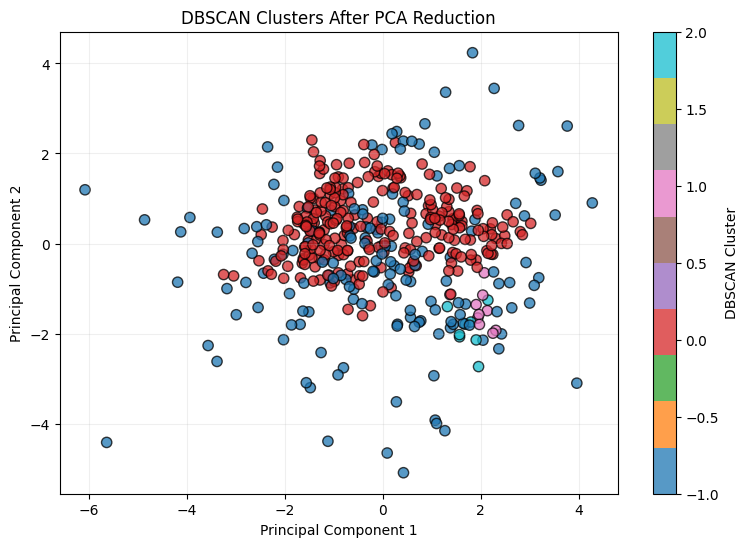

In [33]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["DBSCAN_Cluster"],
    cmap="tab10",
    s=55,
    alpha=0.75,
    edgecolor="black"
)

plt.colorbar(scatter, label="DBSCAN Cluster")
plt.title("DBSCAN Clusters After PCA Reduction")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.2)
plt.show()

In [34]:
kmeans_profile = (
    df.groupby("KMeans_Cluster")[spending_columns]
      .median()
      .round(2)
)

kmeans_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,1492.5,6300.5,10502.5,376.0,4217.5,434.5
1,12126.0,7184.0,9965.0,2005.0,3378.0,2005.0
2,9612.0,1601.0,2155.0,2121.0,274.0,686.0


In [35]:
kmeans_details = []

for cluster in sorted(df["KMeans_Cluster"].unique()):
    cluster_data = df[df["KMeans_Cluster"] == cluster]
    
    dominant_channel_code = cluster_data["Channel"].mode().iloc[0]
    dominant_region_code = cluster_data["Region"].mode().iloc[0]
    
    kmeans_details.append({
        "Cluster": cluster,
        "Customers": len(cluster_data),
        "Percentage": round(len(cluster_data) / len(df) * 100, 2),
        "Dominant Channel": channel_names.get(
            dominant_channel_code,
            dominant_channel_code
        ),
        "Dominant Region": region_names.get(
            dominant_region_code,
            dominant_region_code
        )
    })

kmeans_details_df = pd.DataFrame(kmeans_details)
kmeans_details_df

,Cluster,Customers,Percentage,Dominant Channel,Dominant Region
0,0,80,18.18,Retail,Other
1,1,147,33.41,Retail,Other
2,2,213,48.41,Horeca,Other


In [36]:
kmeans_standardized_profile = (
    X_scaled_df.assign(
        KMeans_Cluster=df["KMeans_Cluster"].values
    )
    .groupby("KMeans_Cluster")
    .mean()
    .round(2)
)

kmeans_standardized_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,-1.18,0.48,0.68,-1.14,0.78,-0.70
1,0.41,0.80,0.74,0.30,0.66,0.68
2,0.16,-0.73,-0.76,0.22,-0.75,-0.21


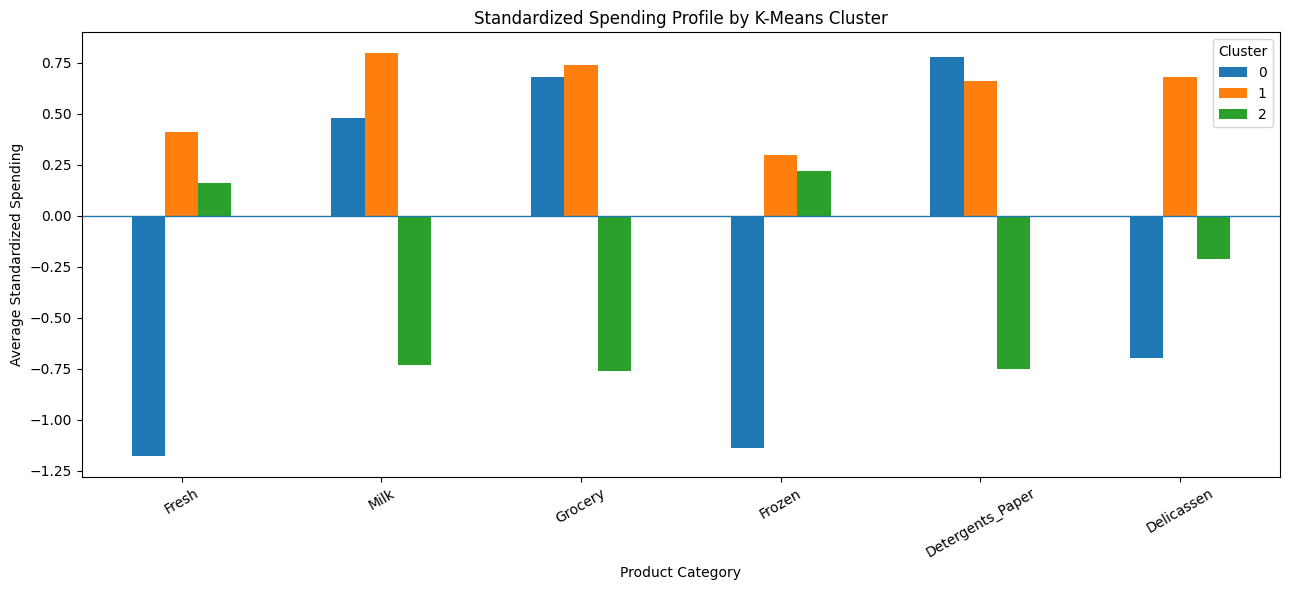

In [37]:
kmeans_standardized_profile.T.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.axhline(0, linewidth=1)
plt.title("Standardized Spending Profile by K-Means Cluster")
plt.xlabel("Product Category")
plt.ylabel("Average Standardized Spending")
plt.xticks(rotation=30)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [38]:
dbscan_profile = (
    df.groupby("DBSCAN_Cluster")[spending_columns]
      .median()
      .round(2)
)

dbscan_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
DBSCAN_Cluster,,,,,,
-1,5858.5,4115.5,5233.5,1155.0,812.0,708.0
0,10075.5,3122.0,3815.5,1797.0,702.0,1040.0
1,1492.5,8445.5,11997.5,133.0,6360.0,1337.5
2,423.0,8604.0,12481.0,771.5,6961.0,263.5


In [39]:
dbscan_details = []

for cluster in sorted(df["DBSCAN_Cluster"].unique()):
    cluster_data = df[df["DBSCAN_Cluster"] == cluster]
    
    dominant_channel_code = cluster_data["Channel"].mode().iloc[0]
    dominant_region_code = cluster_data["Region"].mode().iloc[0]
    
    cluster_name = (
        "Noise / Outliers"
        if cluster == -1
        else f"Cluster {cluster}"
    )
    
    dbscan_details.append({
        "Cluster": cluster_name,
        "Customers": len(cluster_data),
        "Percentage": round(len(cluster_data) / len(df) * 100, 2),
        "Dominant Channel": channel_names.get(
            dominant_channel_code,
            dominant_channel_code
        ),
        "Dominant Region": region_names.get(
            dominant_region_code,
            dominant_region_code
        )
    })

dbscan_details_df = pd.DataFrame(dbscan_details)
dbscan_details_df

,Cluster,Customers,Percentage,Dominant Channel,Dominant Region
0,Noise / Outliers,160,36.36,Horeca,Other
1,Cluster 0,262,59.55,Horeca,Other
2,Cluster 1,10,2.27,Retail,Other
3,Cluster 2,8,1.82,Retail,Other


In [40]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Clusters Found": [
        df["KMeans_Cluster"].nunique(),
        n_dbscan_clusters
    ],
    "Noise Points": [
        0,
        n_noise
    ],
    "Silhouette Score": [
        silhouette_score(
            X_scaled,
            df["KMeans_Cluster"]
        ),
        dbscan_silhouette
    ]
})

comparison.round(3)

,Algorithm,Clusters Found,Noise Points,Silhouette Score
0,K-Means,3,0,0.259
1,DBSCAN,3,160,0.274


K-Means assigns every customer to a cluster and therefore produces a simple, complete market segmentation. DBSCAN does not force every observation into a group and can identify extreme-spending customers as noise. However, DBSCAN is sensitive to the selected eps and min_samples values, especially when customer densities differ. For this dataset, K-Means is usually easier to interpret for customer segmentation, whereas DBSCAN is particularly useful for detecting unusual purchasing patterns.